In [ ]:
import pandas as pd
import gzip

file_path = "/content/GSE4290_series_matrix.txt.gz"

# Read file as raw text
with gzip.open(file_path, 'rt') as f:
    content = f.read()

# Split into lines
lines = content.split('\n')

# Find where data table starts
for i, line in enumerate(lines):
    if line.startswith('"ID_REF"'):
        data_start = i
        break

# Load expression matrix
df = pd.read_csv(file_path,
                 sep="\t",
                 skiprows=data_start)

df.head()

,ID_REF,GSM97793,GSM97794,GSM97795,GSM97796,GSM97797,GSM97798,GSM97799,GSM97800,GSM97801,...,GSM97963,GSM97964,GSM97965,GSM97966,GSM97967,GSM97968,GSM97969,GSM97970,GSM97971,GSM97972
0,1007_s_at,10178.1,10122.9,7826.6,11098.4,8668.9,8659.2,9267.2,4701.5,10702.4,...,11638.7,14652.2,12849.9,11954.4,3929.9,6895.3,14618.3,10016.7,9842.7,8816.4
1,1053_at,388.2,517.5,352.4,609.9,430.1,592.5,378.9,282.7,355.7,...,1229.4,424.0,1023.8,951.7,358.1,338.3,501.2,390.3,606.2,286.9
2,117_at,227.3,460.7,306.0,629.7,551.6,393.6,200.4,769.6,355.2,...,245.4,199.8,634.0,239.3,236.3,232.9,307.1,154.8,486.1,167.8
3,121_at,1665.4,1754.1,1967.0,1521.8,1714.5,1702.0,1552.9,1616.3,1300.9,...,1248.2,1294.2,1416.6,1198.4,1712.3,1500.8,1685.8,1580.5,1620.0,1398.6
4,1255_g_at,90.7,69.1,106.4,39.7,57.3,54.9,60.1,232.7,55.9,...,36.1,75.2,14.3,52.6,162.5,174.4,46.0,102.5,134.4,54.9


In [ ]:
df.shape

(54614, 181)

In [ ]:
# Extract metadata lines
metadata = [line for line in lines if line.startswith("!Sample_source_name_ch1")]

metadata[:2]

['!Sample_source_name_ch1\t"Brain tissue from glioma patient"\t"Brain tissue from glioma patient"\t"Brain tissue from glioma patient"\t"Brain tissue from glioma patient"\t"Brain tissue from glioma patient"\t"Brain tissue from glioma patient"\t"Brain tissue from glioma patient"\t"Brain tissue from epilepsy patient"\t"Brain tissue from glioma patient"\t"Brain tissue from glioma patient"\t"Brain tissue from epilepsy patient"\t"Brain tissue from epilepsy patient"\t"Brain tissue from epilepsy patient"\t"Brain tissue from glioma patient"\t"Brain tissue from epilepsy patient"\t"Brain tissue from glioma patient"\t"Brain tissue from epilepsy patient"\t"Brain tissue from glioma patient"\t"Brain tissue from epilepsy patient"\t"Brain tissue from epilepsy patient"\t"Brain tissue from glioma patient"\t"Brain tissue from glioma patient"\t"Brain tissue from glioma patient"\t"Brain tissue from epilepsy patient"\t"Brain tissue from epilepsy patient"\t"Brain tissue from glioma patient"\t"Brain tissue fro

In [ ]:
# Extract the full metadata line
label_line = metadata[0]

# Split by tab
label_values = label_line.split('\t')[1:]  # skip the first column name

# Clean quotes
label_values = [val.replace('"','').strip() for val in label_values]

len(label_values)

180

In [ ]:
from collections import Counter
Counter(label_values)

Counter({'Brain tissue from glioma patient': 153,
         'Brain tissue from epilepsy patient': 23,
         'Brain tissue from  patient': 4})

In [ ]:
# Find index positions of the weird labels
[i for i, val in enumerate(label_values) if val == 'Brain tissue from  patient']

[33, 43, 65, 86]

In [ ]:
# Get sample names from dataframe
sample_names = df.columns[1:]

weird_indices = [i for i, val in enumerate(label_values) if val == 'Brain tissue from  patient']

sample_names[weird_indices]

Index(['GSM97826', 'GSM97836', 'GSM97858', 'GSM97879'], dtype='object')

In [ ]:
# Create binary labels
labels = []

for val in label_values:
    if "epilepsy" in val.lower():
        labels.append(0)
    else:
        labels.append(1)

from collections import Counter
Counter(labels)

Counter({1: 157, 0: 23})

In [ ]:
# Remove probe ID column
expression_data = df.iloc[:, 1:]

# Transpose
X = expression_data.T

X.shape

(180, 54614)

In [ ]:
#Convert to Numeric
X = X.apply(pd.to_numeric, errors='coerce')
X.isnull().sum().sum()

np.int64(180)

In [ ]:
#Remove Low Variance Genes
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_reduced = selector.fit_transform(X)

X_reduced.shape

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_variance_threshold.py:114: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)


(180, 54613)

In [ ]:
#Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

X_scaled.shape

(180, 54613)

In [ ]:
#PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(180, 149)

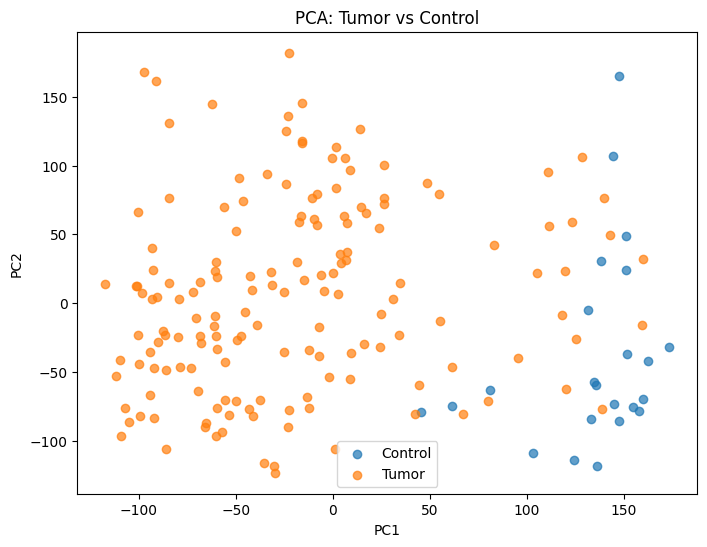

In [ ]:
#Visualize First Two Principal Components
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

for label, color in zip([0,1], ['blue','red']):
    plt.scatter(
        X_pca[np.array(labels)==label, 0],
        X_pca[np.array(labels)==label, 1],
        label='Control' if label==0 else 'Tumor',
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA: Tumor vs Control")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    np.array(labels),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Train distribution:", np.bincount(y_train))
print("Test distribution:", np.bincount(y_test))

Train distribution: [ 18 126]
Test distribution: [ 5 31]


In [ ]:
#Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_model = LogisticRegression(max_iter=5000, class_weight='balanced')
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Confusion Matrix:
 [[ 5  0]
 [ 1 30]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.97      0.98        31

    accuracy                           0.97        36
   macro avg       0.92      0.98      0.95        36
weighted avg       0.98      0.97      0.97        36

ROC-AUC: 1.0


In [ ]:
#Model 2: Support Vector Machine
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', class_weight='balanced', probability=True)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:,1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

Confusion Matrix:
 [[ 4  1]
 [ 1 30]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.97      0.97      0.97        31

    accuracy                           0.94        36
   macro avg       0.88      0.88      0.88        36
weighted avg       0.94      0.94      0.94        36

ROC-AUC: 0.9870967741935484


In [ ]:
#Model 3: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Confusion Matrix:
 [[ 2  3]
 [ 0 31]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.91      1.00      0.95        31

    accuracy                           0.92        36
   macro avg       0.96      0.70      0.76        36
weighted avg       0.92      0.92      0.90        36

ROC-AUC: 1.0


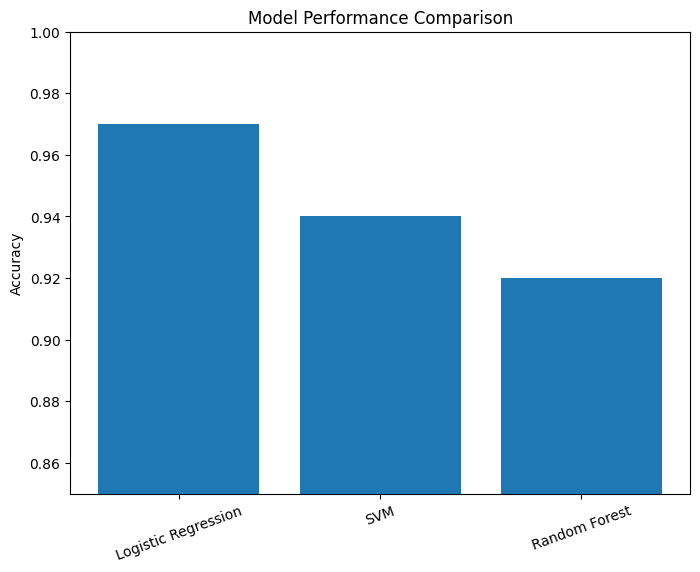

In [ ]:
#Create Performance Comparison Plot
import matplotlib.pyplot as plt

# Model names
models = ["Logistic Regression", "SVM", "Random Forest"]

# Accuracies from your results
accuracies = [0.97, 0.94, 0.92]

plt.figure(figsize=(8,6))
plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.ylim(0.85, 1.0)

plt.xticks(rotation=20)
plt.show()

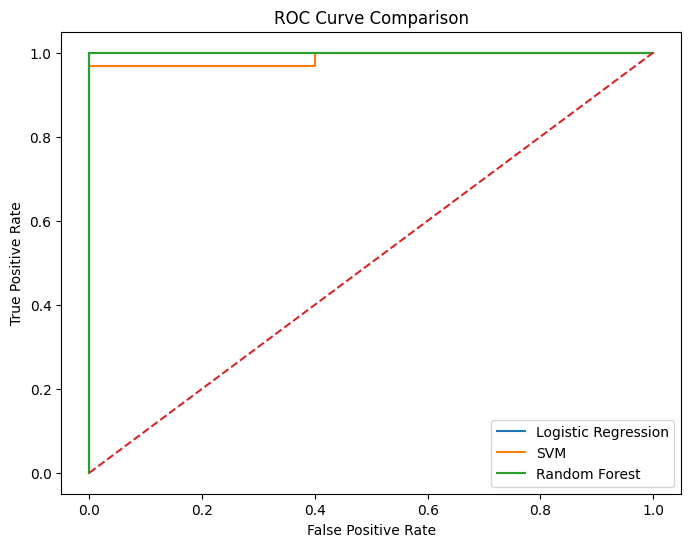

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

# Logistic
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
plt.plot(fpr_log, tpr_log, label="Logistic Regression")

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
plt.plot(fpr_svm, tpr_svm, label="SVM")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
import numpy as np

X_original = X.values
y_array = np.array(labels)

X_original.shape

(180, 54614)

In [ ]:
# Separate tumor and control samples
X_tumor = X_original[y_array == 1]
X_control = X_original[y_array == 0]

print("Tumor shape:", X_tumor.shape)
print("Control shape:", X_control.shape)

Tumor shape: (157, 54614)
Control shape: (23, 54614)


In [ ]:
from scipy.stats import ttest_ind

t_stats, p_values = ttest_ind(
    X_tumor,
    X_control,
    axis=0,
    equal_var=False
)

len(p_values)

54614

In [ ]:
# Get sorted indices
sorted_indices = np.argsort(p_values)

# Top 50 most significant genes
top_50_indices = sorted_indices[:50]

top_50_indices[:10]

array([37292, 31844, 23466, 18523, 10099, 15438,  9998, 44706, 12951,
       24728])

In [ ]:
# Get probe IDs column
probe_ids = df.iloc[:, 0].values

# Extract top 50 probe IDs
top_50_probes = probe_ids[top_50_indices]

top_50_probes[:10]

array(['228038_at', '222565_s_at', '214167_s_at', '209109_s_at',
       '200651_at', '205991_s_at', '200057_s_at', '235457_at',
       '203504_s_at', '215434_x_at'], dtype=object)

In [ ]:
#Load GPL570 Annotation File
import pandas as pd
import gzip

gpl_df = pd.read_csv("GPL570-55999.txt", sep="\t", comment="#")

gpl_df.head()

,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function
0,1007_s_at,U48705,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Huma...,U48705,discoidin domain receptor tyrosine kinase 1 //...,DDR1 /// MIR4640,780 /// 100616237,NM_001202521 /// NM_001202522 /// NM_001202523...,0001558 // regulation of cell growth // inferr...,0005576 // extracellular region // inferred fr...,0000166 // nucleotide binding // inferred from...
1,1053_at,M87338,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,M87338 /FEATURE= /DEFINITION=HUMA1SBU Human re...,M87338,"replication factor C (activator 1) 2, 40kDa",RFC2,5982,NM_001278791 /// NM_001278792 /// NM_001278793...,0000278 // mitotic cell cycle // traceable aut...,0005634 // nucleus // inferred from electronic...,0000166 // nucleotide binding // inferred from...
2,117_at,X51757,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,X51757 /FEATURE=cds /DEFINITION=HSP70B Human h...,X51757,heat shock 70kDa protein 6 (HSP70B'),HSPA6,3310,NM_002155,0000902 // cell morphogenesis // inferred from...,0005737 // cytoplasm // inferred from direct a...,0000166 // nucleotide binding // inferred from...
3,121_at,X69699,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,X69699 /FEATURE= /DEFINITION=HSPAX8A H.sapiens...,X69699,paired box 8,PAX8,7849,NM_003466 /// NM_013951 /// NM_013952 /// NM_0...,0001655 // urogenital system development // in...,0005634 // nucleus // inferred from direct ass...,0000979 // RNA polymerase II core promoter seq...
4,1255_g_at,L36861,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,L36861 /FEATURE=expanded_cds /DEFINITION=HUMGC...,L36861,guanylate cyclase activator 1A (retina),GUCA1A,2978,NM_000409 /// XM_006715073,0007165 // signal transduction // non-traceabl...,0001750 // photoreceptor outer segment // infe...,0005509 // calcium ion binding // inferred fro...


In [ ]:
gpl_df.columns

Index(['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date',
       'Sequence Type', 'Sequence Source', 'Target Description',
       'Representative Public ID', 'Gene Title', 'Gene Symbol',
       'ENTREZ_GENE_ID', 'RefSeq Transcript ID',
       'Gene Ontology Biological Process', 'Gene Ontology Cellular Component',
       'Gene Ontology Molecular Function'],
      dtype='object')

In [ ]:
#Map Top 50 Probes to Gene Symbols
# Create dataframe of top probes
top_probes_df = pd.DataFrame({
    "Probe_ID": top_50_probes
})

# Merge with annotation file
top_genes_df = top_probes_df.merge(
    gpl_df[["ID", "Gene Symbol", "Gene Title"]],
    left_on="Probe_ID",
    right_on="ID",
    how="left"
)

top_genes_df.head(10)

,Probe_ID,ID,Gene Symbol,Gene Title
0,228038_at,228038_at,SOX2,SRY (sex determining region Y)-box 2
1,222565_s_at,222565_s_at,PRKD3,protein kinase D3
2,214167_s_at,214167_s_at,RPLP0,"ribosomal protein, large, P0"
3,209109_s_at,209109_s_at,TSPAN6,tetraspanin 6
4,200651_at,200651_at,GNB2L1 /// SNORD95 /// SNORD96A,guanine nucleotide binding protein (G protein)...
5,205991_s_at,205991_s_at,PRRX1,paired related homeobox 1
6,200057_s_at,200057_s_at,NONO,"non-POU domain containing, octamer-binding"
7,235457_at,NaN,NaN,NaN
8,203504_s_at,203504_s_at,ABCA1,"ATP-binding cassette, sub-family A (ABC1), mem..."
9,215434_x_at,215434_x_at,LOC102724250 /// NBPF1 /// NBPF10 /// NBPF11 /...,neuroblastoma breakpoint family member 1-like ...


In [ ]:
# Add p-values to top genes dataframe
top_genes_df["p_value"] = p_values[top_50_indices]

# Sort by p-value again (just to be safe)
top_genes_df = top_genes_df.sort_values("p_value")

top_genes_df.head(10)

,Probe_ID,ID,Gene Symbol,Gene Title,p_value
0,228038_at,228038_at,SOX2,SRY (sex determining region Y)-box 2,7.250680e-50
1,222565_s_at,222565_s_at,PRKD3,protein kinase D3,1.333754e-46
2,214167_s_at,214167_s_at,RPLP0,"ribosomal protein, large, P0",2.450886e-45
3,209109_s_at,209109_s_at,TSPAN6,tetraspanin 6,2.510687e-45
4,200651_at,200651_at,GNB2L1 /// SNORD95 /// SNORD96A,guanine nucleotide binding protein (G protein)...,3.808708e-45
5,205991_s_at,205991_s_at,PRRX1,paired related homeobox 1,4.997081e-45
6,200057_s_at,200057_s_at,NONO,"non-POU domain containing, octamer-binding",5.033033e-45
7,235457_at,NaN,NaN,NaN,8.193909e-45
8,203504_s_at,203504_s_at,ABCA1,"ATP-binding cassette, sub-family A (ABC1), mem...",1.022980e-44
9,215434_x_at,215434_x_at,LOC102724250 /// NBPF1 /// NBPF10 /// NBPF11 /...,neuroblastoma breakpoint family member 1-like ...,2.629293e-44


In [ ]:
# Select top 20 indices
top_20_indices = sorted_indices[:20]

# Extract expression values for top 20 genes
top_20_data = X_original[:, top_20_indices]

top_20_data.shape

(180, 20)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_heatmap = StandardScaler()
top_20_scaled = scaler_heatmap.fit_transform(top_20_data)

top_20_scaled.shape

(180, 20)

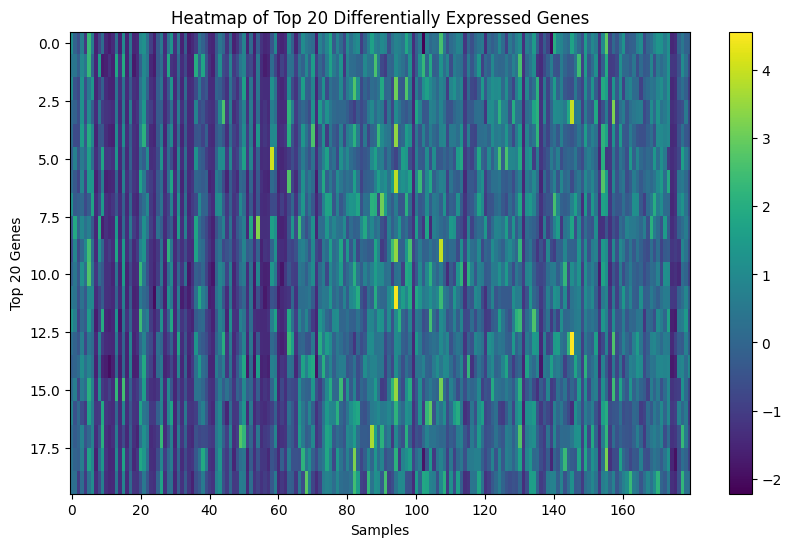

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.imshow(top_20_scaled.T, aspect='auto')

plt.xlabel("Samples")
plt.ylabel("Top 20 Genes")
plt.title("Heatmap of Top 20 Differentially Expressed Genes")

plt.colorbar()
plt.show()

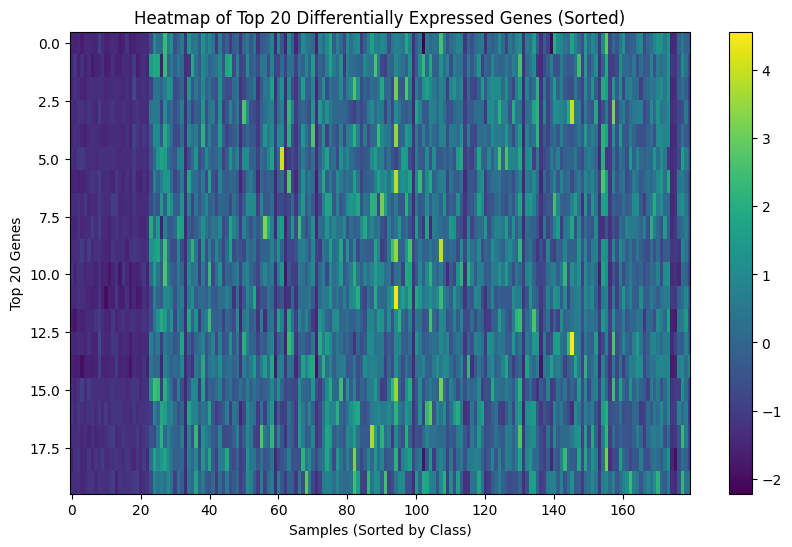

In [ ]:
# Get sorted indices by label (control first, tumor next)
sorted_sample_indices = np.argsort(y_array)

# Reorder heatmap data
top_20_sorted = top_20_scaled[sorted_sample_indices]

# Transpose for plotting
heatmap_data = top_20_sorted.T

plt.figure(figsize=(10,6))
plt.imshow(heatmap_data, aspect='auto')

plt.xlabel("Samples (Sorted by Class)")
plt.ylabel("Top 20 Genes")
plt.title("Heatmap of Top 20 Differentially Expressed Genes (Sorted)")

plt.colorbar()
plt.show()

In [ ]:
#Cross-Validation on Logistic Regression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# Use PCA-reduced data
X_cv = X_pca
y_cv = np.array(labels)

log_model_cv = LogisticRegression(max_iter=5000, class_weight='balanced')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(
    log_model_cv,
    X_cv,
    y_cv,
    cv=skf,
    scoring='accuracy'
)

print("Fold Accuracies:", accuracy_scores)
print("Mean Accuracy:", accuracy_scores.mean())
print("Std Dev:", accuracy_scores.std())

Fold Accuracies: [1.         0.97222222 0.91666667 1.         0.97222222]
Mean Accuracy: 0.9722222222222221
Std Dev: 0.030429030972509243


In [ ]:
from sklearn.model_selection import cross_val_score

roc_scores = cross_val_score(
    log_model_cv,
    X_cv,
    y_cv,
    cv=skf,
    scoring='roc_auc'
)

print("Fold ROC-AUC:", roc_scores)
print("Mean ROC-AUC:", roc_scores.mean())
print("Std Dev:", roc_scores.std())

Fold ROC-AUC: [1.         1.         0.98064516 1.         1.        ]
Mean ROC-AUC: 0.9961290322580645
Std Dev: 0.0077419354838709434


In [ ]:
df = df.set_index("ID_REF")
df = df.T
df.head()

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,91580_at,91617_at,91682_at,91684_g_at,91703_at,91816_f_at,91826_at,91920_at,91952_at,!series_matrix_table_end
GSM97793,10178.1,388.2,227.3,1665.4,90.7,469.9,459.1,20.4,63.8,293.2,...,16.3,697.0,454.3,398.7,154.6,1082.7,75.0,6732.1,226.9,NaN
GSM97794,10122.9,517.5,460.7,1754.1,69.1,495.8,289.2,142.2,30.9,140.0,...,6.9,421.5,534.9,414.6,223.9,1554.6,46.4,2744.1,267.0,NaN
GSM97795,7826.6,352.4,306.0,1967.0,106.4,203.8,266.3,24.3,38.4,386.9,...,5.8,341.0,553.1,453.4,164.2,1139.1,86.0,4231.8,229.4,NaN
GSM97796,11098.4,609.9,629.7,1521.8,39.7,669.3,166.5,64.2,308.4,97.6,...,37.7,347.9,342.7,513.2,328.9,882.3,107.9,2997.4,273.8,NaN
GSM97797,8668.9,430.1,551.6,1714.5,57.3,596.6,212.6,42.8,92.3,116.8,...,13.4,286.9,418.2,336.0,226.7,1493.9,91.8,1618.0,310.9,NaN


In [ ]:
labels = []

for col in df.index:
    if "glioma" in col.lower():
        labels.append(1)
    elif "epilepsy" in col.lower():
        labels.append(0)
    else:
        labels.append(None)

labels = np.array(labels)

In [ ]:
X_full = df.apply(pd.to_numeric, errors='coerce').values
y_full = labels

In [ ]:
probe_ids = df.columns.values  # before transpose

In [ ]:
import numpy as np

X_full = df.apply(pd.to_numeric, errors='coerce').values

# Identify columns that are NOT all NaN
non_nan_columns = ~np.all(np.isnan(X_full), axis=0)

# Filter X
X_full = X_full[:, non_nan_columns]

# Filter probe IDs the same way
probe_ids_filtered = probe_ids[non_nan_columns]

print(X_full.shape)
print(len(probe_ids_filtered))

(180, 54613)
54613


In [ ]:
import numpy as np
np.isnan(X_full).sum()

np.int64(0)

In [ ]:
# Extract source names line
for line in lines:
    if line.startswith("!Sample_source_name_ch1"):
        source_line = line
        break

# Split into values
sources = source_line.strip().split("\t")[1:]
sources = [s.replace('"','') for s in sources]

# Create labels
labels = []

for s in sources:
    if "epilepsy" in s.lower():
        labels.append(0)
    else:
        labels.append(1)  # everything else is tumor

y_full = np.array(labels)

print("Unique labels:", np.unique(y_full))
print("Counts:", np.bincount(y_full))

Unique labels: [0 1]
Counts: [ 23 157]


In [ ]:
print(X_full.shape)
print(y_full.shape)

(180, 54613)
(180,)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
import numpy as np

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("logreg", LogisticRegression(max_iter=5000, class_weight='balanced'))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(pipeline, X_full, y_full, cv=skf, scoring='accuracy')
cv_auc = cross_val_score(pipeline, X_full, y_full, cv=skf, scoring='roc_auc')

print("Pipeline CV Accuracy:", cv_accuracy)
print("Mean Accuracy:", cv_accuracy.mean())
print("Std Accuracy:", cv_accuracy.std())

print("\nPipeline CV ROC-AUC:", cv_auc)
print("Mean ROC-AUC:", cv_auc.mean())
print("Std ROC-AUC:", cv_auc.std())

Pipeline CV Accuracy: [0.97222222 0.97222222 0.88888889 0.97222222 1.        ]
Mean Accuracy: 0.961111111111111
Std Accuracy: 0.03767961101736262

Pipeline CV ROC-AUC: [1.         1.         0.98064516 1.         1.        ]
Mean ROC-AUC: 0.9961290322580645
Std ROC-AUC: 0.0077419354838709434


In [ ]:
#Proper Differential Expression (With FDR)
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

# Separate groups
X_tumor = X_full[y_full == 1]
X_normal = X_full[y_full == 0]

# Perform t-test for each gene
t_stats, p_values = ttest_ind(X_tumor, X_normal, axis=0, equal_var=False)

# FDR correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Create results DataFrame
deg_results = pd.DataFrame({
    "Probe_ID": probe_ids_filtered,  # Make sure this matches filtered X
    "p_value": p_values,
    "adj_p_value": pvals_corrected,
    "significant": reject
})

# Keep significant genes
deg_significant = deg_results[deg_results["significant"] == True]
deg_significant = deg_significant.sort_values("adj_p_value")

deg_significant.head(20)

,Probe_ID,p_value,adj_p_value,significant
37292,228038_at,7.250680e-50,3.959814e-45,True
31844,222565_s_at,1.333754e-46,3.642016e-42,True
23466,214167_s_at,2.450886e-45,3.427904e-41,True
18523,209109_s_at,2.510687e-45,3.427904e-41,True
15438,205991_s_at,4.997081e-45,3.926700e-41,True
10099,200651_at,3.808708e-45,3.926700e-41,True
9998,200057_s_at,5.033033e-45,3.926700e-41,True
44706,235457_at,8.193909e-45,5.593674e-41,True
12951,203504_s_at,1.022980e-44,6.207558e-41,True
24728,215434_x_at,2.629293e-44,1.435936e-40,True


In [ ]:
merged_deg = deg_results.merge(
    gpl_df[['ID', 'Gene Symbol', 'Gene Title', 'Gene Ontology Biological Process']],
    left_on='Probe_ID',
    right_on='ID',
    how='left'
)

top20_genes = merged_deg[merged_deg['significant'] == True]\
                .sort_values('adj_p_value')\
                .head(20)

top20_genes[['Probe_ID','Gene Symbol','Gene Title','adj_p_value']]

,Probe_ID,Gene Symbol,Gene Title,adj_p_value
37292,228038_at,SOX2,SRY (sex determining region Y)-box 2,3.959814e-45
31844,222565_s_at,PRKD3,protein kinase D3,3.642016e-42
23466,214167_s_at,RPLP0,"ribosomal protein, large, P0",3.427904e-41
18523,209109_s_at,TSPAN6,tetraspanin 6,3.427904e-41
15438,205991_s_at,PRRX1,paired related homeobox 1,3.926700e-41
10099,200651_at,GNB2L1 /// SNORD95 /// SNORD96A,guanine nucleotide binding protein (G protein)...,3.926700e-41
9998,200057_s_at,NONO,"non-POU domain containing, octamer-binding",3.926700e-41
44706,235457_at,NaN,NaN,5.593674e-41
12951,203504_s_at,ABCA1,"ATP-binding cassette, sub-family A (ABC1), mem...",6.207558e-41
24728,215434_x_at,LOC102724250 /// NBPF1 /// NBPF10 /// NBPF11 /...,neuroblastoma breakpoint family member 1-like ...,1.435936e-40


In [ ]:
deg_significant.shape

(29798, 4)

In [ ]:
top100 = merged_deg[merged_deg['significant'] == True]\
            .sort_values('adj_p_value')\
            .head(100)

top100[['Gene Symbol', 'Gene Ontology Biological Process']].head(20)

,Gene Symbol,Gene Ontology Biological Process
37292,SOX2,0000122 // negative regulation of transcriptio...
31844,PRKD3,0006468 // protein phosphorylation // inferred...
23466,RPLP0,0000184 // nuclear-transcribed mRNA catabolic ...
18523,TSPAN6,0007165 // signal transduction // inferred fro...
15438,PRRX1,0000122 // negative regulation of transcriptio...
10099,GNB2L1 /// SNORD95 /// SNORD96A,0001934 // positive regulation of protein phos...
9998,NONO,0006281 // DNA repair // inferred from electro...
44706,NaN,NaN
12951,ABCA1,0002790 // peptide secretion // inferred from ...
24728,LOC102724250 /// NBPF1 /// NBPF10 /// NBPF11 /...,NaN


In [ ]:
import numpy as np

# Means and standard deviations
mean_tumor = X_tumor.mean(axis=0)
mean_normal = X_normal.mean(axis=0)

std_tumor = X_tumor.std(axis=0, ddof=1)
std_normal = X_normal.std(axis=0, ddof=1)

# Pooled std
pooled_std = np.sqrt((std_tumor**2 + std_normal**2) / 2)

# Cohen's d
cohen_d = (mean_tumor - mean_normal) / pooled_std

# Add to dataframe
deg_results["cohen_d"] = cohen_d

In [ ]:
deg_results.sort_values("adj_p_value").head(20)[
    ["Probe_ID","adj_p_value","cohen_d"]
]

,Probe_ID,adj_p_value,cohen_d
37292,228038_at,3.959814e-45,2.611270
31844,222565_s_at,3.642016e-42,2.555279
23466,214167_s_at,3.427904e-41,2.334504
18523,209109_s_at,3.427904e-41,2.266225
10099,200651_at,3.926700e-41,2.346688
15438,205991_s_at,3.926700e-41,2.246268
9998,200057_s_at,3.926700e-41,2.390451
44706,235457_at,5.593674e-41,2.264971
12951,203504_s_at,6.207558e-41,2.307582
24728,215434_x_at,1.435936e-40,2.257418


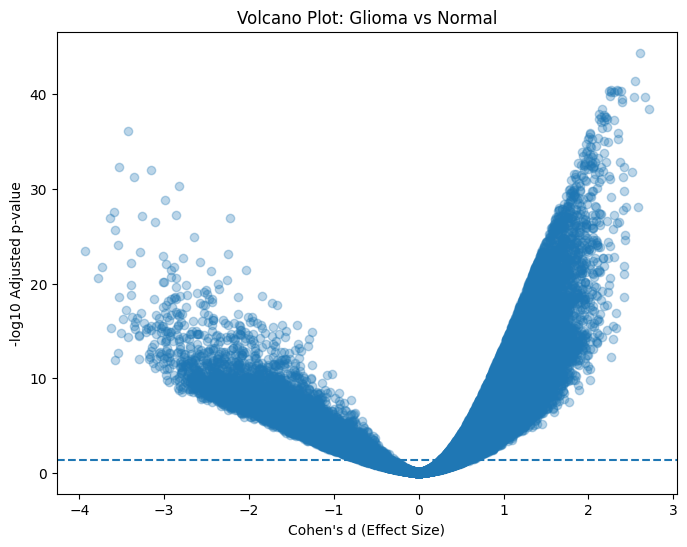

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

log_p = -np.log10(deg_results["adj_p_value"])

plt.scatter(cohen_d, log_p, alpha=0.3)

plt.xlabel("Cohen's d (Effect Size)")
plt.ylabel("-log10 Adjusted p-value")
plt.title("Volcano Plot: Glioma vs Normal")

plt.axhline(-np.log10(0.05), linestyle='--')
plt.show()

In [ ]:
top100 = merged_deg[merged_deg['significant'] == True]\
            .sort_values('adj_p_value')\
            .head(100)

In [ ]:
process_text = top100["Gene Ontology Biological Process"].dropna()

# Flatten GO terms
all_terms = []
for entry in process_text:
    terms = str(entry).split("///")
    for t in terms:
        all_terms.append(t.strip())

from collections import Counter
Counter(all_terms).most_common(15)

[('0010467 // gene expression // traceable author statement', 17),
 ('0006351 // transcription, DNA-templated // inferred from electronic annotation',
  13),
 ('0044267 // cellular protein metabolic process // traceable author statement',
  12),
 ('0006412 // translation // traceable author statement', 10),
 ('0016032 // viral process // traceable author statement', 10),
 ('0007275 // multicellular organismal development // inferred from electronic annotation',
  9),
 ('0006614 // SRP-dependent cotranslational protein targeting to membrane // traceable author statement',
  9),
 ('0008152 // metabolic process // inferred from electronic annotation', 9),
 ('0016070 // RNA metabolic process // traceable author statement', 8),
 ('0016071 // mRNA metabolic process // traceable author statement', 8),
 ('0000184 // nuclear-transcribed mRNA catabolic process, nonsense-mediated decay // traceable author statement',
  7),
 ('0006413 // translational initiation // traceable author statement', 7),

In [ ]:
#Minimal Gene Classifier
#Select Top N Genes by Effect Size
# Sort genes by absolute effect size
deg_results_sorted = deg_results.sort_values(by="cohen_d", key=abs, ascending=False)

top5_genes = deg_results_sorted.head(5)["Probe_ID"].values
top10_genes = deg_results_sorted.head(10)["Probe_ID"].values
top20_genes = deg_results_sorted.head(20)["Probe_ID"].values

In [ ]:
#Create Reduced Feature Matrices
# Create mapping from probe IDs to column indices
probe_to_index = {probe: idx for idx, probe in enumerate(probe_ids_filtered)}

def get_matrix(selected_probes):
    indices = [probe_to_index[p] for p in selected_probes]
    return X_full[:, indices]

X_top5 = get_matrix(top5_genes)
X_top10 = get_matrix(top10_genes)
X_top20 = get_matrix(top20_genes)

In [ ]:
#Evaluate Performance for Each
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

def evaluate_model(X):
    pipeline_small = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=5000, class_weight='balanced'))
    ])

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    acc = cross_val_score(pipeline_small, X, y_full, cv=skf, scoring='accuracy')
    auc = cross_val_score(pipeline_small, X, y_full, cv=skf, scoring='roc_auc')

    return acc.mean(), auc.mean()

results = {
    "Top 5": evaluate_model(X_top5),
    "Top 10": evaluate_model(X_top10),
    "Top 20": evaluate_model(X_top20),
}

results

{'Top 5': (np.float64(0.961111111111111), np.float64(0.9942943548387098)),
 'Top 10': (np.float64(0.961111111111111), np.float64(0.9958568548387097)),
 'Top 20': (np.float64(0.95), np.float64(0.9930040322580644))}

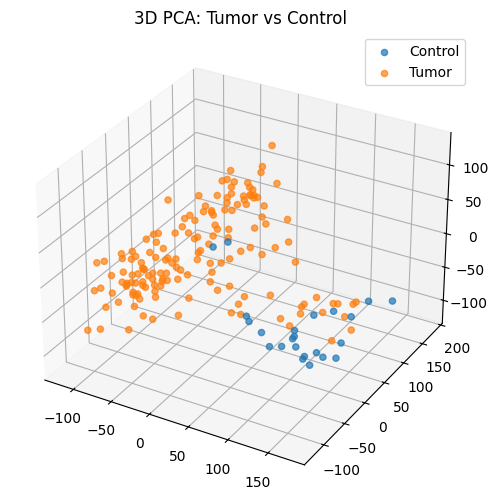

In [ ]:
#3D PCA Visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(StandardScaler().fit_transform(X_full))

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca_3d[y_full==0,0],
           X_pca_3d[y_full==0,1],
           X_pca_3d[y_full==0,2],
           label="Control", alpha=0.7)

ax.scatter(X_pca_3d[y_full==1,0],
           X_pca_3d[y_full==1,1],
           X_pca_3d[y_full==1,2],
           label="Tumor", alpha=0.7)

ax.set_title("3D PCA: Tumor vs Control")
ax.legend()
plt.show()

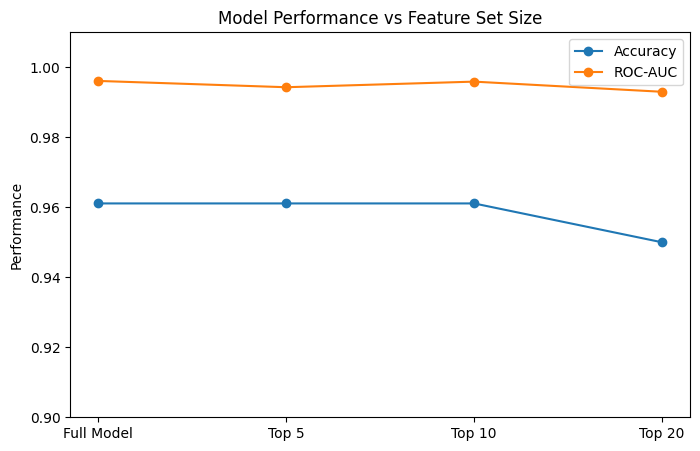

In [ ]:
import matplotlib.pyplot as plt

models = ["Full Model", "Top 5", "Top 10", "Top 20"]

accuracies = [
    0.9611,   # full model mean accuracy
    0.9611,
    0.9611,
    0.95
]

auc_scores = [
    0.9961,   # full model mean AUC
    0.9943,
    0.9959,
    0.9930
]

x = range(len(models))

plt.figure(figsize=(8,5))
plt.plot(x, accuracies, marker='o', label="Accuracy")
plt.plot(x, auc_scores, marker='o', label="ROC-AUC")

plt.xticks(x, models)
plt.ylabel("Performance")
plt.ylim(0.9, 1.01)
plt.title("Model Performance vs Feature Set Size")
plt.legend()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

selection_matrix = []

for train_idx, test_idx in skf.split(X_full, y_full):

    X_train, y_train = X_full[train_idx], y_full[train_idx]

    pipeline_l1 = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("lasso", LogisticRegression(
            penalty='l1',
            solver='liblinear',
            class_weight='balanced',
            max_iter=5000
        ))
    ])

    pipeline_l1.fit(X_train, y_train)

    # Get selected features
    coef = pipeline_l1.named_steps["lasso"].coef_[0]
    selected = np.abs(coef) > 1e-6

    selection_matrix.append(selected)

selection_matrix = np.array(selection_matrix)

# Compute selection frequency
selection_freq = selection_matrix.mean(axis=0)

stability_df = pd.DataFrame({
    "Probe_ID": probe_ids_filtered,
    "Selection_Frequency": selection_freq
})

stable_genes = stability_df.sort_values(
    "Selection_Frequency", ascending=False
).head(20)

stable_genes

,Probe_ID,Selection_Frequency
36275,227020_at,1.0
50191,240942_at,1.0
11789,202341_s_at,1.0
151,1552473_at,1.0
20420,211056_s_at,1.0
16608,207162_s_at,1.0
12228,202780_at,1.0
49761,240512_x_at,1.0
20423,211059_s_at,1.0
24314,215020_at,1.0


In [ ]:
#Merge Stability with DEG Results
# Merge differential expression results with stability results
core_df = deg_results.merge(
    stability_df,
    on="Probe_ID",
    how="inner"
)

# Filter for strong genes
core_signature = core_df[
    (core_df["adj_p_value"] < 0.05) &
    (abs(core_df["cohen_d"]) > 2.0) &
    (core_df["Selection_Frequency"] >= 0.8)
]

# Sort by stability first, then effect size
core_signature = core_signature.sort_values(
    by=["Selection_Frequency", "cohen_d"],
    ascending=[False, False]
)

core_signature.head(20)

,Probe_ID,p_value,adj_p_value,significant,cohen_d,Selection_Frequency
50191,240942_at,9.553346e-08,4.996044e-07,True,-2.041111,1.0
24314,215020_at,2.574286e-07,1.243384e-06,True,-2.064321,1.0
23232,213933_at,1.001128e-07,5.215050e-07,True,-2.098628,1.0
12228,202780_at,3.390293e-08,1.929492e-07,True,-2.215337,1.0
20420,211056_s_at,1.373233e-09,1.018756e-08,True,-2.460699,1.0
151,1552473_at,2.911091e-11,2.966108e-10,True,-2.599082,1.0
41064,231810_at,1.195220e-10,1.089907e-09,True,-2.642315,1.0
51122,241873_at,2.837950e-10,2.399210e-09,True,-2.693333,1.0
49761,240512_x_at,3.148266e-10,2.634023e-09,True,-2.793941,1.0
36275,227020_at,1.642520e-11,1.748596e-10,True,-2.876412,1.0


In [ ]:
#Add Gene Symbols
core_signature_annot = core_signature.merge(
    gpl_df[["ID", "Gene Symbol", "Gene Title"]],
    left_on="Probe_ID",
    right_on="ID",
    how="left"
)

core_signature_annot = core_signature_annot[[
    "Probe_ID",
    "Gene Symbol",
    "adj_p_value",
    "cohen_d",
    "Selection_Frequency"
]]

core_signature_annot.head(20)

,Probe_ID,Gene Symbol,adj_p_value,cohen_d,Selection_Frequency
0,240942_at,NaN,4.996044e-07,-2.041111,1.0
1,215020_at,NRXN3,1.243384e-06,-2.064321,1.0
2,213933_at,PTGER3,5.215050e-07,-2.098628,1.0
3,202780_at,OXCT1,1.929492e-07,-2.215337,1.0
4,211056_s_at,SRD5A1,1.018756e-08,-2.460699,1.0
5,1552473_at,GAMT,2.966108e-10,-2.599082,1.0
6,231810_at,NaN,1.089907e-09,-2.642315,1.0
7,241873_at,NaN,2.399210e-09,-2.693333,1.0
8,240512_x_at,NaN,2.634023e-09,-2.793941,1.0
9,227020_at,YPEL2,1.748596e-10,-2.876412,1.0


In [ ]:
#Variance-Based Gene Filtering
import numpy as np
from sklearn.feature_selection import VarianceThreshold

# Compute variance of each gene
gene_variances = np.var(X_full, axis=0)

# Get indices of top 1000 most variable genes
top_var_indices = np.argsort(gene_variances)[-1000:]

X_top_var = X_full[:, top_var_indices]

print("Top-variable matrix shape:", X_top_var.shape)

Top-variable matrix shape: (180, 1000)


In [ ]:
#Evaluate Raw vs PCA vs Top-Var
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(X):
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=5000, class_weight='balanced'))
    ])

    acc = cross_val_score(pipeline, X, y_full, cv=skf, scoring='accuracy')
    auc = cross_val_score(pipeline, X, y_full, cv=skf, scoring='roc_auc')

    return acc.mean(), acc.std(), auc.mean(), auc.std()

# Raw
raw_results = evaluate_model(X_full)

# PCA
pipeline_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("logreg", LogisticRegression(max_iter=5000, class_weight='balanced'))
])

acc_pca = cross_val_score(pipeline_pca, X_full, y_full, cv=skf, scoring='accuracy')
auc_pca = cross_val_score(pipeline_pca, X_full, y_full, cv=skf, scoring='roc_auc')

pca_results = (acc_pca.mean(), acc_pca.std(), auc_pca.mean(), auc_pca.std())

# Top Variable
top_var_results = evaluate_model(X_top_var)

print("Raw:", raw_results)
print("PCA:", pca_results)
print("Top Variable:", top_var_results)

Raw: (np.float64(0.961111111111111), np.float64(0.05152010275275389), np.float64(0.9987096774193549), np.float64(0.0025806451612902844))
PCA: (np.float64(0.961111111111111), np.float64(0.03767961101736262), np.float64(0.9961290322580645), np.float64(0.0077419354838709434))
Top Variable: (np.float64(0.9777777777777776), np.float64(0.03239417719358502), np.float64(0.9961290322580645), np.float64(0.0077419354838709434))


In [ ]:
#Random Forest Feature Importance
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_pipeline.fit(X_full, y_full)

rf_model = rf_pipeline.named_steps["rf"]

importances = rf_model.feature_importances_

# Get top 10 important genes
top10_rf_indices = np.argsort(importances)[-10:][::-1]

top10_rf_probes = [probe_ids_filtered[i] for i in top10_rf_indices]
top10_rf_importance = importances[top10_rf_indices]

rf_top_df = pd.DataFrame({
    "Probe_ID": top10_rf_probes,
    "Importance": top10_rf_importance
})

rf_top_df

,Probe_ID,Importance
0,204547_at,0.012970
1,217762_s_at,0.008535
2,209839_at,0.007648
3,225240_s_at,0.007284
4,201599_at,0.007268
5,225025_at,0.007131
6,221918_at,0.006811
7,202178_at,0.006665
8,228051_at,0.005922
9,215434_x_at,0.005748


In [ ]:
#Map RF Top Genes to Symbols
rf_top_annot = rf_top_df.merge(
    gpl_df,
    left_on="Probe_ID",
    right_on="ID",
    how="left"
)

rf_top_annot = rf_top_annot[[
    "Probe_ID",
    "Gene Symbol",
    "Gene Title",
    "Importance"
]]

rf_top_annot

,Probe_ID,Gene Symbol,Gene Title,Importance
0,204547_at,RAB40B,"RAB40B, member RAS oncogene family",0.012970
1,217762_s_at,RAB31,"RAB31, member RAS oncogene family",0.008535
2,209839_at,DNM3,dynamin 3,0.007648
3,225240_s_at,MSI2,musashi RNA-binding protein 2,0.007284
4,201599_at,OAT,ornithine aminotransferase,0.007268
5,225025_at,IGSF8,"immunoglobulin superfamily, member 8",0.007131
6,221918_at,CDK17,cyclin-dependent kinase 17,0.006811
7,202178_at,PRKCZ,"protein kinase C, zeta",0.006665
8,228051_at,KIAA1244,KIAA1244,0.005922
9,215434_x_at,LOC102724250 /// NBPF1 /// NBPF10 /// NBPF11 /...,neuroblastoma breakpoint family member 1-like ...,0.005748


In [ ]:
#Cross-Validated Sensitivity & Specificity
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
import numpy as np

# Use best-performing setup (Top Variable filtering)
pipeline_final = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, class_weight='balanced'))
])

# Cross-validated predictions
y_pred = cross_val_predict(
    pipeline_final,
    X_top_var,
    y_full,
    cv=skf
)

# Confusion matrix
cm = confusion_matrix(y_full, y_pred)
tn, fp, fn, tp = cm.ravel()

# Sensitivity & Specificity
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Confusion Matrix:\n", cm)
print("Sensitivity (Recall - Tumor):", sensitivity)
print("Specificity (Recall - Control):", specificity)

Confusion Matrix:
 [[ 23   0]
 [  4 153]]
Sensitivity (Recall - Tumor): 0.9745222929936306
Specificity (Recall - Control): 1.0


In [ ]:
#Linear vs RBF SVM Comparison
from sklearn.svm import SVC

def evaluate_svm(kernel_type):
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel=kernel_type, probability=True, class_weight='balanced'))
    ])

    acc = cross_val_score(pipeline, X_top_var, y_full, cv=skf, scoring='accuracy')
    auc = cross_val_score(pipeline, X_top_var, y_full, cv=skf, scoring='roc_auc')

    return acc.mean(), acc.std(), auc.mean(), auc.std()

svm_linear = evaluate_svm("linear")
svm_rbf = evaluate_svm("rbf")

print("SVM Linear:", svm_linear)
print("SVM RBF:", svm_rbf)

SVM Linear: (np.float64(0.9888888888888889), np.float64(0.013608276348795441), np.float64(0.9961290322580645), np.float64(0.0077419354838709434))
SVM RBF: (np.float64(0.9277777777777778), np.float64(0.033333333333333305), np.float64(0.9891330645161289), np.float64(0.00897673385928516))


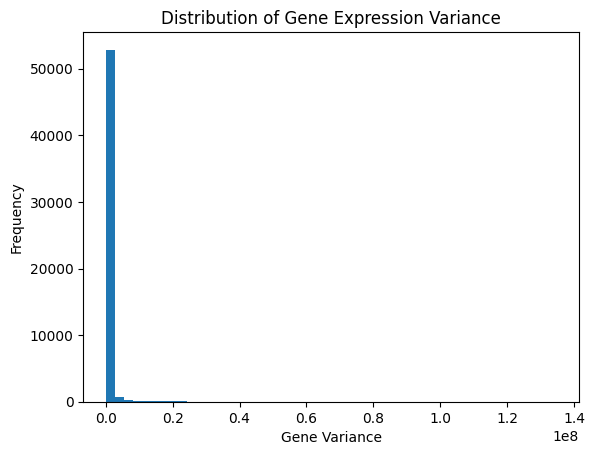

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# X = gene expression matrix (samples × genes)
gene_variances = np.var(X, axis=0)

plt.figure()
plt.hist(gene_variances, bins=50)
plt.xlabel("Gene Variance")
plt.ylabel("Frequency")
plt.title("Distribution of Gene Expression Variance")
plt.show()

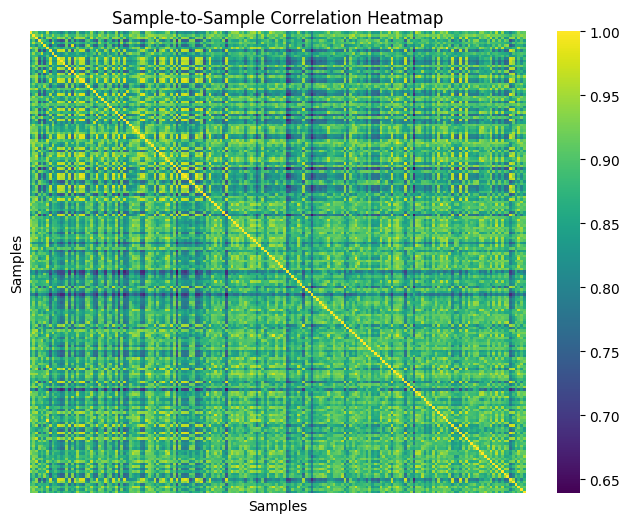

Min correlation: 0.6388494247753898
Max correlation: 1.0


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute sample-to-sample correlation
corr_matrix = np.corrcoef(X_full)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, cmap="viridis",
            xticklabels=False, yticklabels=False)

plt.title("Sample-to-Sample Correlation Heatmap")
plt.xlabel("Samples")
plt.ylabel("Samples")
plt.show()

print("Min correlation:", np.min(corr_matrix))
print("Max correlation:", np.max(corr_matrix))

In [ ]:
# Extract metadata lines
metadata = [line for line in lines if line.startswith("!Sample_source_name_ch1")]

# Extract the full metadata line
label_line = metadata[0]

# Split by tab
label_values = label_line.split('\t')[1:]  # skip the first column name

# Clean quotes
label_values = [val.replace('"','').strip() for val in label_values]

# Create binary labels
labels = []

for val in label_values:
    if "epilepsy" in val.lower():
        labels.append(0)
    else:
        labels.append(1)


# Remove probe ID column
expression_data = df.iloc[:, 1:]

# Transpose
X = expression_data.T

#Convert to Numeric
X = X.apply(pd.to_numeric, errors='coerce')

X_original = X.values
y_array = np.array(labels)

# Correctly get gene probe IDs from the 'ID_REF' column of the original df
probe_ids = df['ID_REF'].values

# Filter out columns that are entirely NaN after conversion
# Identify columns that are NOT all NaN
non_nan_columns = ~np.all(np.isnan(X_original), axis=0)

# Filter X
X_full = X_original[:, non_nan_columns]

# Filter probe IDs the same way
probe_ids_filtered = probe_ids[non_nan_columns]

# Extract source names line from the original `lines` (from first cell)
for line in lines:
    if line.startswith("!Sample_source_name_ch1"):
        source_line = line
        break

# Split into values
sources = source_line.strip().split("\t")[1:]
sources = [s.replace('"','') for s in sources]

# Create labels (y_full)
labels_full = []

for s in sources:
    if "epilepsy" in s.lower():
        labels_full.append(0)
    else:
        labels_full.append(1)  # everything else is tumor

y_full = np.array(labels_full)

print("X_full shape:", X_full.shape)
print("y_full shape:", y_full.shape)

X_full shape: (180, 54613)
y_full shape: (180,)


In [ ]:
import pandas as pd
import gzip

file_path = "/content/GSE4290_series_matrix.txt.gz"

# Read file as raw text
with gzip.open(file_path, 'rt') as f:
    content = f.read()

# Split into lines
lines = content.split('\n')

# Find where data table starts
for i, line in enumerate(lines):
    if line.startswith('"ID_REF"'):
        data_start = i
        break

# Load expression matrix
df = pd.read_csv(file_path,
                 sep="\t",
                 skiprows=data_start)

df.head()

,ID_REF,GSM97793,GSM97794,GSM97795,GSM97796,GSM97797,GSM97798,GSM97799,GSM97800,GSM97801,...,GSM97963,GSM97964,GSM97965,GSM97966,GSM97967,GSM97968,GSM97969,GSM97970,GSM97971,GSM97972
0,1007_s_at,10178.1,10122.9,7826.6,11098.4,8668.9,8659.2,9267.2,4701.5,10702.4,...,11638.7,14652.2,12849.9,11954.4,3929.9,6895.3,14618.3,10016.7,9842.7,8816.4
1,1053_at,388.2,517.5,352.4,609.9,430.1,592.5,378.9,282.7,355.7,...,1229.4,424.0,1023.8,951.7,358.1,338.3,501.2,390.3,606.2,286.9
2,117_at,227.3,460.7,306.0,629.7,551.6,393.6,200.4,769.6,355.2,...,245.4,199.8,634.0,239.3,236.3,232.9,307.1,154.8,486.1,167.8
3,121_at,1665.4,1754.1,1967.0,1521.8,1714.5,1702.0,1552.9,1616.3,1300.9,...,1248.2,1294.2,1416.6,1198.4,1712.3,1500.8,1685.8,1580.5,1620.0,1398.6
4,1255_g_at,90.7,69.1,106.4,39.7,57.3,54.9,60.1,232.7,55.9,...,36.1,75.2,14.3,52.6,162.5,174.4,46.0,102.5,134.4,54.9
